<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [4]:
import pandas as pd
import psycopg2
import warnings
import numpy as np
import os
from dotenv import load_dotenv
# библиотеки, небходимые для визуализации
import plotly
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

In [5]:
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", DeprecationWarning)

In [6]:
load_dotenv()
DBNAME = os.getenv("DBNAME")
USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
HOST = os.getenv("HOST")
PORT = os.getenv("PORT")

In [7]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [9]:
# текст запроса
query_3_1 = f'''
select distinct
    count(v.name)
from vacancies v
'''

In [13]:
# результат запроса
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)
display(f'Вакансий в базе: {int(pd.read_sql_query(query_3_1, connection).iloc[0])}')
connection.close()

'Вакансий в базе: 49197'

2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [11]:
# текст запроса
query_3_2 = f'''
select distinct
    count(e.id)
from employers e
'''

In [14]:
# результат запроса
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)
display(f'Работодателей в таблице employers: {int(pd.read_sql_query(query_3_2, connection).iloc[0])}')
connection.close()

'Работодателей в таблице employers: 23501'

3. Посчитате с помощью запроса количество регионов (таблица areas).

In [ ]:
# текст запроса
query_3_3 = f'''
select distinct
    count(a.id)
from areas a
'''

In [ ]:
# результат запроса
display(f'Регионов в таблице areas: {int(pd.read_sql_query(query_3_3, connection).iloc[0])}')

'Регионов в таблице areas: 1362'

4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [ ]:
# текст запроса
query_3_4= f'''
select distinct
    count(i.id)
from industries i
'''

In [ ]:
# результат запроса
display(f'Количество сфер деятельности в базе: {int(pd.read_sql_query(query_3_4, connection).iloc[0])}')

'Количество сфер деятельности в базе: 294'

***

## *Выводы по предварительному анализу данных:*

В результате предварительного анализа данных мы выявили:
* **49197** уникальных размещенных вакансий
* **23501** уникальны работодателя
* Вакансии размещены в **1362** регионах (городах)
* Для соискателей доступны **294** сферы деятельности 

---

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [ ]:
# текст запроса
query_4_1= f'''
select 
    a.name area,
    count(v.id) cnt
from 
    areas a
    join vacancies v on a.id = v.area_id
group by a.name 
order by 2 desc

limit 5
'''

In [ ]:
# результат запроса
res_4_1 = pd.read_sql_query(query_4_1, connection)
print('Топ-5 регионов по количеству размещенных вакансий:')
display(res_4_1)

Топ-5 регионов по количеству размещенных вакансий:


,area,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [ ]:
# текст запроса
query_4_2 = f'''
select 
    count(v.id) result
from 
    vacancies v
where salary_from is not null or salary_to is not null
'''

In [ ]:
# результат запроса
display(f'Заполнено хотя бы одно из двух полей с зарплатой у {int(pd.read_sql_query(query_4_2, connection).iloc[0])} количества вакансий')

'Заполнено хотя бы одно из двух полей с зарплатой у 24073 количества вакансий'

3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [ ]:
# текст запроса
query_4_3= f'''
select 
    round(avg(v.salary_from)) "Среднее значение для нижней границы вилки зп",
    round(avg(v.salary_to)) "Среднее значение для верхней границы вилки зп"
from 
    vacancies v
'''

In [ ]:
# результат запроса
res_4_3 = pd.read_sql_query(query_4_3, connection)
print('Cредние значения для нижней и верхней границы зарплатной вилки')
res_4_3

Cредние значения для нижней и верхней границы зарплатной вилки


,Среднее значение для нижней грани,Среднее значение для верхней гран
0,71065.0,110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [ ]:
# текст запроса
query_4_4 = f'''
select distinct
    v.schedule,
    v.employment,
    count(v.id)
from 
    vacancies v
group by v.schedule, v.employment
order by count(v.id) desc
offset 1 limit 1
'''

In [ ]:
# результат запроса
res_4_4 = pd.read_sql_query(query_4_4, connection)
print('Вторая пара по количеству вакансий по графику и типу:')
res_4_4

Вторая пара по количеству вакансий по графику и типу:


,schedule,employment,count
0,Удаленная работа,Полная занятость,7802


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [ ]:
# текст запроса
query_4_5 = f'''
select 
    v.experience,
    count(v.id)
from 
    vacancies v
group by v.experience
order by count(v.id) 
'''

In [ ]:
# результат запроса
res_4_5 = pd.read_sql_query(query_4_5, connection)
print('Значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта:')
res_4_5

Значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта:


,experience,count
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

## *Выводы по детальному анализу вакансий:*

В результате проведения детального анализа вакансий выявлено:
* Лидерство по количеству вакансий держат столицы РФ(Москва, СПб), респ.Беларусь и города миллионники (Новосибирск  г. Алматы(респ.Казахстан))
* Только у **48.9%** вакансий заполнено хотя бы одно из двух полей с ЗП. Это значит, что **более чем у половины вакансий не указаны зарплатные предложения**
* Среди указанных значений ЗП средней минимальной заработной платой является **71065** руб., средней максимальной - **110537** руб.
* По сочетанию значений "Рабочего графика" и "Типа трудоустройства" 5-ка лидерства следующие сочетания: "Полный день - Полная занятость", "Удаленная работа - Полная занятость", "Гибкий график - Полная занятость", "Удаленная работа - Частичная занятость", "Сменный график - Полная занятость"
* Достаточно удивительными кажутся результаты количества вакансий в разрезе опыта соискаетелй. Так, меньше всего вакансий для **наиболее опытных сотрудников от 6 лет**, далее по возрастающей для людей **без опыта работы**, далее **от 3 до 6 лет** и максимальное количество вакансий для соискателей с опытом работы **от 1 до 3 лет**

---

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [ ]:
# текст запроса
query_5_1 = f'''
select 
    e.name,
    count(v.id)
from 
    employers e
join vacancies v on e.id = v.employer_id
group by e.name
order by count(v.id) desc
limit 5
'''

In [ ]:
# результат запроса
res_5_1 = pd.read_sql_query(query_5_1, connection)
display(f'Первое место: {res_5_1.iloc[0][0]}')
display(f'Пятое место: {res_5_1.iloc[4][0]}')
res_5_1

'Первое место: Яндекс'

'Пятое место: Газпром нефть'

,name,count
0,Яндекс,1933
1,Ростелеком,491
2,Тинькофф,444
3,СБЕР,428
4,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [ ]:
# текст запроса
query_5_2 = f'''
select 
    a.name регион,
    count(e.id) "Количество работадателей",
    count(v.id) "Количество вакансий"
from 
    areas a 
left join employers e on a.id = e.area
left join vacancies v  on a.id = v.area_id
group by a.name
having count(v.id) = 0
order by 2 desc
limit 1
'''

In [ ]:
# результат запроса
res_5_2 = pd.read_sql_query(query_5_2, connection)
display(f'Регион в котором больше всего работодателей, но нет вакансий: {res_5_2.iloc[0][0]}')

'Регион в котором больше всего работодателей, но нет вакансий: Россия'

3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [ ]:
# текст запроса
query_5_3 = f'''
select 
	e.name,
	count(distinct area_id) 
from 
    vacancies v
join employers e on v.employer_id = e.id
GROUP BY 1
ORDER BY 2 DESC
LIMIT 1
'''

In [ ]:
# результат запроса
res_5_3 = pd.read_sql_query(query_5_3, connection)
display(f'Максимальное количество регионов, в котором публикуется работодатель: {res_5_3.iloc[0][1]}, это компания: {res_5_3.iloc[0][0]}')

'Максимальное количество регионов, в котором публикуется работодатель: 181, это компания: Яндекс'

4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [ ]:
# текст запроса
query_5_4 = f'''
select 
	count(e.id)
from 
    employers e
    left join employers_industries ei on e.id = ei.employer_id
    left join industries i on i.id = ei.industry_id
where i.name is null
group by i.name
'''

In [ ]:
# результат запроса
res_5_4 = pd.read_sql_query(query_5_4, connection)
display(f'Количество работадателей, у которых не указана сфера деятельности: {int(res_5_4.iloc[0])}')

'Количество работадателей, у которых не указана сфера деятельности: 8419'

5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [ ]:
# текст запроса
query_5_5 = f'''
select 
	e.name
from 
    employers e
    left join employers_industries ei on e.id = ei.employer_id
    left join industries i on i.id = ei.industry_id
group by e.name
having count(i.id) = 4
order by 1
offset 2 limit 1
'''

In [ ]:
# результат запроса
res_5_5 = pd.read_sql_query(query_5_5, connection)
display('Наименование компании : {}'.format(res_5_5.iloc[0]['name']))

'Наименование компании : 2ГИС'

6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [ ]:
# текст запроса
query_5_6 = f'''
select 
	count(e.id)
from 
    employers e
    left join employers_industries ei on e.id = ei.employer_id
    left join industries i on i.id = ei.industry_id
where i.name like 'Разработка программного обеспечения'
group by i.name
'''

In [ ]:
# результат запроса
res_5_6 = pd.read_sql_query(query_5_6, connection)
display('Количество работодателей, работающих в сфере деятельности «Разработка программного обеспечения».: {}'.format(int(res_5_6.iloc[0])))

'Количество работодателей, работающих в сфере деятельности «Разработка программного обеспечения».: 3553'

7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [ ]:
# текст запроса
query_5_7 = f'''
select 
    a.name,
    count(v.id) cnt
from 
    vacancies v
    join areas a on a.id = v.area_id
    join employers e on v.employer_id = e.id
where   e.name like'Яндекс' and 
        (a.name like 'Москва' or
        a.name like 'Санкт-Петербург' or
        a.name like 'Новосибирск' or
        a.name like 'Екатеринбург' or
        a.name like 'Казань' or
        a.name like 'Красноярск' or
        a.name like 'Нижний Новгород' or
        a.name like 'Челябинск' or
        a.name like 'Уфа' or
        a.name like 'Краснодар' or
        a.name like 'Самара' or
        a.name like 'Ростов-на-Дону' or
        a.name like 'Омск' or
        a.name like 'Воронеж' or
        a.name like 'Пермь' or
        a.name like 'Волгоград')
group by  a.name 

union all

select 
    'Total',
    count(v.id) 
from 
    vacancies v
    join areas a on a.id = v.area_id
    join employers e on v.employer_id = e.id
where   e.name like'Яндекс' and 
        (a.name like 'Москва' or
        a.name like 'Санкт-Петербург' or
        a.name like 'Новосибирск' or
        a.name like 'Екатеринбург' or
        a.name like 'Казань' or
        a.name like 'Красноярск' or
        a.name like 'Нижний Новгород' or
        a.name like 'Челябинск' or
        a.name like 'Уфа' or
        a.name like 'Краснодар' or
        a.name like 'Самара' or
        a.name like 'Ростов-на-Дону' or
        a.name like 'Омск' or
        a.name like 'Воронеж' or
        a.name like 'Пермь' or
        a.name like 'Волгоград')
 order by 2
'''

In [ ]:
# результат запроса
res_5_7 = pd.read_sql_query(query_5_7, connection)
display('Сколько строк получилось в выборке: {}'.format(res_5_7.shape[0]))
display('Результат получился в строке Total: {}'.format(int(res_5_7[res_5_7['name'] == 'Total']['cnt'])))

'Сколько строк получилось в выборке: 17'

'Результат получился в строке Total: 485'

***

## *Выводы по анализу работодателей:*

В результате анализа работодателей мы выяснили:
* первая пятерка работодателей по количеству вакансий следующая: Яндекс, Ростелеком, Тинькофф, СБЕР, Газпром нефть
* лидерство среди регионов по количеству работодателей и вакансий занимают столицы и крупнейие города-миллионники РФ, РБ и Казахстана. При этом Москва лидирует с огромным отрывом. Список топ-10 городов по убыванию каоличества работодателей и вакансий: Москва, Санкт-Петербург, Минск, Алматы, Новосибирск, Екатеринбург, Нижний Новгород, Казань, Краснодар, Ростов-на-Дону. При этом, среди регионов, в которых нет вакансий, но, в котором наибольшее количество работодателей - Россия - 410 работодателей
* среди работодателей лидерство по числу регионов, в которых он публикует свои вакансии, занимает Яндекс - 181 регион (город) публикации вакансий
* в списке работодателей присутствует 8419 организаций, у которых не указана сфера деятельности
* в списке 1136 компаний, у которых указано 4 сферы деятельности
* среди всех сфер деятельности указано 3553 компании со сферой деятельности  «Разработка программного обеспечения»
* конкретно для компании Яндекс в городах-миллионниках опубликовано 485 вакансий в 16 городах

---

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [ ]:
# текст запроса
query_6_1 = f'''
select 
	count(v.id)
from 
    vacancies v
where lower(v.name) like '%данн%' or lower(v.name) like '%data%'
'''

In [ ]:
# результат запроса
res_6_1 = pd.read_sql_query(query_6_1, connection)
display(f'К данным имеют отношение {int(res_6_1.iloc[0])} вакансия')

'К данным имеют отношение 1771 вакансия'

2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [ ]:
# текст запроса
query_6_2 = f'''
select 
	count(v.id)
from 
    vacancies v
where (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      ((v.name ilike '%ML%') and (v.name not ilike '%HTML%')) or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%') 
      and
      (v.name ilike '%junior%' or
      v.experience ilike 'Нет опыта' or
      v.employment ilike 'Стажировка')
      '''

In [ ]:
# результат запроса
res_6_2 = pd.read_sql_query(query_6_2, connection)
display(f'Для начинающего дата-сайентиста есть {int(res_6_2.loc[0])} подходящая вакансия')

'Для начинающего дата-сайентиста есть 51 подходящая вакансия'

3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [ ]:
# текст запроса
query_6_3 = f'''
select 
	count(v.id)
from 
    vacancies v
where (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      ((v.name ilike '%ML%') and (v.name not ilike '%HTML%')) or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%')
and
    (v.key_skills like '%SQL%' or 
    v.key_skills like '%postgres%')
'''

In [ ]:
# результат запроса
res_6_3 = pd.read_sql_query(query_6_3, connection)
display(f'Условиям задачи соответствует {int(res_6_3.loc[0])} вакансий')

'Условиям задачи соответствует 229 вакансий'

4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [ ]:
# текст запроса
query_6_4 = f'''
select 
	count(v.id)
from 
    vacancies v
where (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      ((v.name ilike '%ML%') and (v.name not ilike '%HTML%')) or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%')
and
    (v.key_skills like '%Python%' )
'''

In [ ]:
# результат запроса
res_6_4 = pd.read_sql_query(query_6_4, connection)
display(f'Условиям задачи соответствует {int(res_6_4.loc[0])} вакансий')

'Условиям задачи соответствует 357 вакансий'

5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [ ]:
# текст запроса
query_6_5 = f'''
select 
	avg(length(v.key_skills)-length(replace(v.key_skills,chr(9),''))+1)
from 
    vacancies v
where v.key_skills is not null and 
      (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      v.name like '%ML%' or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%')
      and (v.name not ilike '%HTML%')
'''

In [ ]:
# результат запроса
res_6_5 = round(pd.read_sql_query(query_6_5, connection),2)
display(f'В вакансиях для DS в среднем указывают {float(res_6_5.loc[0])} ключевых навыков')

'В вакансиях для DS в среднем указывают 6.41 ключевых навыков'

6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [ ]:
# текст запроса
query_6_6 = f'''
select 
	v.experience,
	avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to))  salary
from 
    vacancies v
where 
      (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      v.name like '%ML%' or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%')
      and (v.name not ilike '%HTML%')
group by v.experience
'''

In [ ]:
# результат запроса
res_6_6 = round(pd.read_sql_query(query_6_6, connection))
display('Средняя з/п для DS с опытом работы от 3 до 6 лет: {}'.format(int(
    res_6_6[res_6_6['experience'] == 'От 3 до 6 лет']['salary'])))
res_6_6

'Средняя з/п для DS с опытом работы от 3 до 6 лет: 243115'

,experience,salary
0,Более 6 лет,NaN
1,Нет опыта,74643.0
2,От 1 года до 3 лет,139675.0
3,От 3 до 6 лет,243115.0


***

## *Выводы по предметному анализу:*

В результате предметноо анализа по профессии дата-сайнс мы получили следующие результаты:
* Если из общего количества вакансий считать упоминания -data и -данн, то таких вакансий 1771
* Если брать более конкретные указатели на профессию, такие как "data scientist", "data science", "исследователь данных", "ML", "machine learning", "машинн%обучен%", а так же конкретизируя позицию junior, то таких вакансий 51
* Далее исследования касались позиции Дата-сайентист, а так же поиск согласно ключевым навыкам. Конкретно по навыку SQL и Postreg размещено 229 вакансий
* Требования ключевого навыка Python указаны в 357 вакансиях
* Так же в вакансиях по DS размещено в среднем 6.41 различных ключевых навыка
* Финальное исследование касалось средней ЗП в зависимости от опыта работы. Логично предположить, что с ростом опыта, растет и уровень ЗП, это полностью подтвердилось исследованием.

---

# Общий вывод по проекту

**Задачей** данного проекта является анализ резюме с сайта Head Hunter средствами SQL и Python. Я научился делать запросы к базе данных с таблицами через запрос в среде Python, что для меня стало приятным завершением курса по SQL.
Работа над проектом строилась из следующих этапов:
1. знакомство с данными, представленными 5 таблицами

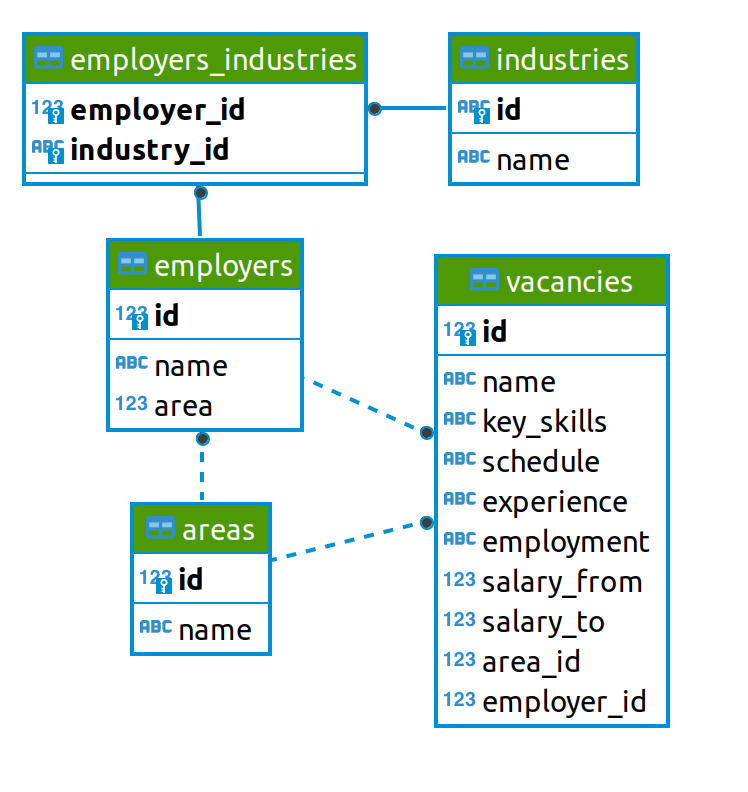

Ключевая таблица ```vacancies``` содержит ключевые данные по самим вакансиям, зар.платам, опыту работу, графику и пр., таблица ```areas``` содержит в себе регионы(города), таблица ```employers``` содержит информацию о работодателях и географии присутствия, таблица ```industries``` рассказываем нам о сферах деятельности, и финальная таблица ```employers_industries``` является технической для связи работодателей и индустрии.

2. на следующем этапе  был проведен предварительный анализ данных, в результате которых мы получили общие представленияо количестве вакансий, работодателей и других ключевых данных из разных таблиц.

3. при более детальном анализе ```вакансий``` мы познакомились с различными сочетаниями данных из этой таблицы. Такими как количество вакансий в разных регионах, информация о зп, графике и типе трудоустройства

4. на этом этапе мы рассматривали ```работодателей``` по количеству вакансий, их географии присутствия и сфер деятельности.

5. ну и на финальном этапе анализа мы уже более детально рассмотрели вопрос профессии ```DS```, вакансий в которых упоминаются ключевые навыки, требования, зарплаты и знания

На мой взгляд, в рамках данного проекта мы очень поверхностно прошли по материалу данны, выполнили поставленные задачи, можно было углубиться в любой из описанных выше этапов анализа, однако это уже задача более углубленного анализа.

В качестве дополнительного задания я хочу рассмотреть следующие вопросы:
* ***География размещенных вакансий***. Интересно посмотреть насыщенность предложений в различных регионах страны, подтвердить или опровергнуть сосредоточенность локализации предложений работы вокруг городов-миллионников (в рамках проекта мы смотрели лишь присутствие компании Яндекс в городах миллионниках)
* ***Разбивка вакансий по уровням ЗП***. Интересно посмотреть, какие вакансии, в каких регионах в какой сфере деятельности предлагают какие уровни заработка для соискателей
* Интересно проанализировать, есть ли связь ***количества вакансий и среднего уровня зп*** на примере городов-миллионников, как концентраторов рабочих ресурсов
* Хотелось бы расширить изучение предложений в сфере  ***DS***, а именно посмотреть на работодателей, регионы и количество вакансий в этой сфере
* Ну и в финале хотел бы разбить 100% вакансий по сферам деятельности и посмотреть  на количество вакансий во всех представленных индустриях

## <center> Задача 1.
География вакансий в России

In [ ]:
query_01 = f'''
select 
    a.name region,
    count(v.id)  "Количество вакансий"
from
    areas a
join vacancies v on a.id = v.area_id
group by a.name
order by 1
'''

In [ ]:
df_01 = pd.read_sql_query(query_01, connection)
display(df1.head())

,region,Количество вакансий
0,Абакан,37
1,Абан,1
2,Абдулино,1
3,Абинск,6
4,Абхазия,1


In [ ]:
# Таблица cities2 создана на базе таблице с координатами всех городов РФ. Оставлены лишь столбцы с названием,
# широтой и долготой
c1 = pd.read_csv('cities2.csv', sep = ';')
display(c1[c1['Город']=='Москва'])
# к сожалению по соображениям безопасности город Москва и Санкт-Петербург отсутствую в таблице с точными координатами.
# поэтому отразить их на карте нет возможности. Это я увидел уже в процессе реализации.

,Город,Широта,Долгота


In [ ]:
# Объединяю таблицу с координатами городов с полученным дата-фреймом из sql. Метод 'inner' выбран, чтобы исключить
# регионы вне РФ, а также такие у которых нет координат, например "Россия", "Абхазия" и пр.
merged = c1.merge(
    df_01,
    left_on='Город',
    right_on ='region',
    how='inner'
)
# Так как в таблице есть столбец "Город", удаляем столбец "region"
df_02 = merged.drop('region', axis = 1)

In [ ]:
fig = go.Figure(go.Scattermapbox(lat=df_02['Широта'], 
                                 lon=df_02['Долгота'], 
                                 text=df_02['Город'],
                                 marker=dict(colorbar=dict(title="Количество вакансий"),
                                             color=df_02['Количество вакансий'],
                                             )))
map_center = go.layout.mapbox.Center(lat=(df_02['Широта'].max()+df_02['Широта'].min())/2, 
                                     lon=(df_02['Долгота'].max()+df_02['Долгота'].min())/2)
fig.update_layout(mapbox_style="open-street-map",
                  mapbox=dict(center=map_center, zoom=2))
fig.show()

>Выводы: изначально целью данноо исследования была карта с нанесенными городами (регионами) с маркером количества вакансий. Чтобы посмотреть как много где вакансий. В связи с тем, что в базе данных представлены не только города России, но также страны СНГ, Европы и др, пришлось чистить данные и оставлять только данные по РФ. К сожалению знаний по ```Scattermapbox``` не хватает, чтобы сделать график более информативным. Четкий вывод можно сделать такой: основная масса регионов имеет менее 1000 вакансий, что подтверждается синим цветом маркера

К сожалению не доволен результатом работы, так как не смог вывести помимо названия города - количество вакансий в нем.
Так же на графике нет крупнейших агломераций таких как Москва и Спб. График получился неинформативным. Но работа была проделана, решил оставить.

---
## <center> Задача 2
Рассмотрим взаимосвязь количества размещенных вакансий и средней ЗП в городах-миллионниках

In [ ]:
# создаем запрос
query_02 = f'''
select 
    a.name Город,
    count(v.id) "Количество вакансий",
    avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to))  "Средняя ЗП в регионе"
from
    areas a
join vacancies v on a.id = v.area_id
where   (a.name like 'Москва' or
        a.name like 'Санкт-Петербург' or
        a.name like 'Новосибирск' or
        a.name like 'Екатеринбург' or
        a.name like 'Казань' or
        a.name like 'Красноярск' or
        a.name like 'Нижний Новгород' or
        a.name like 'Челябинск' or
        a.name like 'Уфа' or
        a.name like 'Краснодар' or
        a.name like 'Самара' or
        a.name like 'Ростов-на-Дону' or
        a.name like 'Омск' or
        a.name like 'Воронеж' or
        a.name like 'Пермь' or
        a.name like 'Волгоград')
group by a.name
order by 2 desc
'''

In [ ]:
# результат запроса
df_03 = pd.read_sql_query(query_02, connection)
display(df_03)

,Город,Количество вакансий,Средняя ЗП в регионе
0,Москва,5333,134140.171482
1,Санкт-Петербург,2851,104409.772236
2,Новосибирск,2006,107776.716900
3,Екатеринбург,1698,91895.745838
4,Нижний Новгород,1670,96058.730882
5,Казань,1415,92207.383758
6,Краснодар,1301,92328.215007
7,Самара,1144,80223.106931
8,Ростов-на-Дону,1131,94065.385621
9,Воронеж,1063,84958.184154


In [ ]:
fig = make_subplots(rows=1, cols=2,subplot_titles=("Количество вакансий в городах", "Уровни ЗП в городах"))
fig.add_trace(go.Bar(x = df_03['Город'], y = df_03['Количество вакансий'], name = "Вакансий в разных городах"),1,1)
fig.add_trace(go.Bar(x = df_03['Город'], y = df_03['Средняя ЗП в регионе'], name = "ЗП в разных городах"),1,2)
fig.update_layout(legend_orientation="v",
                  legend=dict(x=.8, xanchor="center"),

                  xaxis_title="города",
                  yaxis_title="Вакансии",
                  margin=dict(l=0, r=0, t=30, b=0))
fig.show()

>Выводы: 
* Москва занимает лидирующую роль и по количеству вакансий, и по средней зп.
* Наши данные отсортированы по уменьшению количества вакансий. 
* Уровень зп не всем соответствует количеству вакансий. Так, например, Новосибирск опережает Санкт-Петербург по средней ЗП, Екатеринбург имеет меньшую среднюю зп, чем Н.Новгород, Казань и Краснодар, ну и др.
* Можно сделать вывод, что при общей тенденции по уменьшению количества вакансий в городах, уровень падения средней зп соответсвует падению количеству вакансий, за исключением некоторых городов

---
## <center> Задача 3
Рассмотрим, какие вакансии, в каких регионах в какой сфере деятельности предлагают какие уровни заработка для соискателей

In [ ]:
query_03 = f'''
select 
    avg(coalesce((v.salary_from + v.salary_to) / 2, v.salary_from, v.salary_to))  "Средняя ЗП",
    a.name Город
from
    vacancies v
join areas a on a.id = v.area_id
join employers e on e.id = v.employer_id
join employers_industries ei on ei.employer_id = e.id
join industries i on i.id = ei.industry_id

group by a.name
having avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) is not null
order by avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) desc
'''

In [ ]:
df_03 = pd.read_sql_query(query_03, connection)
display(df_03.head())

,Средняя ЗП,Город
0,350691.0,Литва
1,321467.0,Кутаиси
2,314160.5,Дзержинск (Беларусь)
3,300000.0,Испания
4,277630.2,Черногория


In [ ]:
fig = px.treemap(
    data_frame=df_03, #DataFrame
    path=['Город'], #категориальный признак, для которого строится график
    values='Средняя ЗП', #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Распределение уровня ЗП в зависимости от региона' #заголовок
)

fig.show()

>**Выводы:**
* По графику заметно, что максимальные уровни зп предлагаются не в городах, а странах:Литва, Испания, Черногоря, Болгария, США и др.

In [ ]:
query_04 = f'''
select 
    avg(coalesce((v.salary_from + v.salary_to) / 2, v.salary_from, v.salary_to))  "Средняя ЗП",
    i.name Индустрия
from
    vacancies v
join areas a on a.id = v.area_id
join employers e on e.id = v.employer_id
join employers_industries ei on ei.employer_id = e.id
join industries i on i.id = ei.industry_id

group by i.name
having avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) is not null
order by avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) desc
'''

In [ ]:
df_04 = pd.read_sql_query(query_04, connection)
display(df_04.head())

,Средняя ЗП,Индустрия
0,381428.571429,"Агрохимия (продвижение, оптовая торговля)"
1,339875.000000,Агрохимия (производство)
2,191904.900000,Игорный бизнес
3,168299.827586,Корма для животных (производство)
4,167612.903226,Зоомагазин


In [ ]:
fig = px.treemap(
    data_frame=df_04, #DataFrame
    path=['Индустрия'], #категориальный признак, для которого строится график
    values='Средняя ЗП', #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Распределение уровня ЗП в зависимости от индустрии' #заголовок
)

fig.show()

>**Выводы:**
* неожиаднным выводом стало, что индустрия "Агрохимия" занимает лидирующие позиции по уровню ЗП

---
## <center> Задача 4

Сфера  ***DS***, а именно посмотреть на работодателей, регионы и количество вакансий в этой сфере

In [ ]:
# Посмотрим на географию вакансий и уровень ЗП по DS
query_05 = f'''
select 
   -- i.name,
    a.name Город,
    avg(coalesce((v.salary_from + v.salary_to) / 2, v.salary_from, v.salary_to))  "Средняя ЗП"
from
    vacancies v
join areas a on a.id = v.area_id
join employers e on e.id = v.employer_id
join employers_industries ei on ei.employer_id = e.id
join industries i on i.id = ei.industry_id

where 
      (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      v.name like '%ML%' or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%')
      and (v.name not ilike '%HTML%')
group by a.name --, i.name
having avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) is not null
order by avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) desc
'''

In [ ]:
df_05 = pd.read_sql_query(query_05, connection)
display(df_05.head(3))

,Город,Средняя ЗП
0,Кипр,300000.000000
1,Армения,268862.666667
2,Москва,240454.545455


In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(x = df_05['Город'], y = df_05['Средняя ЗП']))
fig.update_layout(legend_orientation="v",
                  legend=dict(x=.8, xanchor="center"),
                  title="Уровень зп  DS в разных городах",
                  xaxis_title="города",
                  yaxis_title="ЗП",
                  margin=dict(l=0, r=0, t=30, b=20))
fig.show()

>**Вывод:**
* лидирующие регионы по уровню ЗП DS занимают страны, а не города - Кипр, Армения, Турция и др.
* среди городов в России традиционно рейтинг возглавляет Москва, СПб, и удивительно Белгород

In [ ]:
# Посмотрим на индустрии, в которых требуются специалисты DS и уровень ЗП, которые предлагают
query_06 = f'''
select 
    i.name "Сфера деятельности",
   -- a.name Город,
    avg(coalesce((v.salary_from + v.salary_to) / 2, v.salary_from, v.salary_to))  "Средняя ЗП"
from
    vacancies v
join areas a on a.id = v.area_id
join employers e on e.id = v.employer_id
join employers_industries ei on ei.employer_id = e.id
join industries i on i.id = ei.industry_id

where 
      (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      v.name like '%ML%' or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%')
      and (v.name not ilike '%HTML%')
group by /*a.name,*/ i.name
having avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) is not null
order by avg(coalesce((salary_from + salary_to) / 2, salary_from, salary_to)) desc
'''

In [ ]:
df_06 = pd.read_sql_query(query_06, connection)
display(df_06.head())

,Сфера деятельности,Средняя ЗП
0,"Маркетинговые, рекламные, BTL, дизайнерские, E...",350000.0
1,Лизинговые компании,300000.0
2,Кадровые агентства,237500.0
3,Издательская деятельность,236023.5
4,Консалтинговые услуги,222500.0


In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(x = df_06['Сфера деятельности'], y = df_06['Средняя ЗП']))
fig.update_layout(legend_orientation="v",
                  legend=dict(x=.8, xanchor="center"),
                  title="Уровень зп в разных индустрия",
                  xaxis_title="Индустрии",
                  yaxis_title="ЗП",
                  margin=dict(l=0, r=0, t=30, b=0))
fig.show()

>**Выводы:**
* удивило распределение сфер, в которых требуются специалисты DS: маркетинг, лизинг, кадры, издательство, консалтинг и только потом разработка ПО
* наука и гос.управление находится лишь в середине списка
* удивительно, что банковская сфера находится на последнем месте по количеству вакансий DS

In [ ]:
# Посмотрим на количество вакансий DS в разных городах
query_07 = f'''
select 
    
    a.name Город,
    count(v.id)  "Кол-во вакансий"
from
    vacancies v
join areas a on a.id = v.area_id
join employers e on e.id = v.employer_id
join employers_industries ei on ei.employer_id = e.id
join industries i on i.id = ei.industry_id

where 
      (v.name ilike '%data scientist%' or 
      v.name ilike '%data science%' or
      v.name ilike '%исследователь данных%' or
      v.name like '%ML%' or
      v.name ilike '%machine learning%' or
      v.name ilike '%машинн%обучен%')
      and (v.name not ilike '%HTML%')
group by a.name

order by count(v.id) desc
'''

In [ ]:
df_07 = pd.read_sql_query(query_07, connection)
display(df_07.head(3))

,Город,Кол-во вакансий
0,Москва,335
1,Санкт-Петербург,127
2,Новосибирск,49


In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(x = df_07['Город'], y = df_07['Кол-во вакансий']))
fig.update_layout(legend_orientation="v",
                  legend=dict(x=.8, xanchor="center"),
                  title="Количество вакансий DS в разных городах",
                  xaxis_title="города",
                  yaxis_title="Количество вакансий",
                  margin=dict(l=0, r=0, t=30, b=50))
fig.show()

>**Выводы:**
* Москва занимает лидирующую позицию по количеству вакансий DS, более чем в 2 раза меньше вакансий в СПб, еще в 2.5 раза меньше в Новосибирске

---
## <center> Задача 5

Разобьем 100% вакансий по сферам деятельности и посмотрим  на количество вакансий во всех представленнызх инустриях

In [ ]:
# Проанализируем общее количество вакансий во всех индустриях с разбивкой по индустриям
query_08 = f'''
select 
    i.name "Сфера деятельности",
    count(v.id)  "Кол-во вакансий"
from
    vacancies v
join employers e on e.id = v.employer_id
join employers_industries ei on ei.employer_id = e.id
join industries i on i.id = ei.industry_id

group by i.name
order by count(v.id) desc
'''

In [ ]:
df_08 = pd.read_sql_query(query_08, connection)
display(df_08.head())

,Сфера деятельности,Кол-во вакансий
0,Разработка программного обеспечения,12499
1,"Системная интеграция, автоматизации технологи...",11034
2,"Интернет-компания (поисковики, платежные систе...",6413
3,Банк,2742
4,Мобильная связь,1585


In [ ]:
fig = px.treemap(
    data_frame=df_08, #DataFrame
    path=['Сфера деятельности'], #категориальный признак, для которого строится график
    values='Кол-во вакансий', #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Количество вакансий в разных индустриях' #заголовок
)

fig.show()

>**Выводы:**
* Больше всего вакансий в 3 крупнейших индустриях - IT сфера
* Далее по убыванию идут Банки, телеком и далее